<a href="https://colab.research.google.com/github/martinroth25/ai_transportation_course/blob/main/Exercise_2_regression_model/Assignment_1_Regression_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 1: Demand prediction of bike sharing system**

Bike sharing services are nowadays spread all over the world. They are beneficial for cities as they offer a climate neutral and healthy way of transportation. Moreover, similar to e-scooters, for the companies and transportation researchers they generate valuable data. This includes the trip route, trip origins and destinations, duration, and much more.

In this assignment we use a public bike sharing dataset from Washington, D.C., USA. published by Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894.

## Your Task

Your task in this assignment is:

1) to predict the demand of hourly rentals (**target-column: cnt**) using the [XGBoost](https://xgboost.readthedocs.io/en/stable/) and linear regression model. In this notebook we have provided you with the basic structure how to approach the problem. Feel free to reuse and improve parts of the exercise material.

2) After you have created the model please upload your code to Github and post the link to the notebook in the corresponding forum for the assignment with a short text describing how you have solved the task.

## Load data

You can also find more information about the data and the columns at: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [1]:
import pandas as pd

url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'
df = pd.read_csv(url)

#df = pd.read_csv('Exercise2BikeSharing.csv')
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [2]:
df.shape

(17379, 17)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Train / Test split
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

In [4]:
from sklearn.model_selection import train_test_split
target = 'cnt'

X = df.copy()
y = df[target].astype(float)

X.drop(columns=[target], inplace=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [5]:
X.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6


## Data Processing / Feature Engineering

Before training the model think about data processing and feature engineering steps if applicable, such as:
- adding/removal of features
- normalization
- one hot encoding
- ...


In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

cols_to_drop = ['instant', 'dteday', 'casual', 'registered']
X_train.drop(columns=cols_to_drop, inplace=True, errors='ignore')
X_test.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# One-hot encoding of categorical features that aren't binary
categorical_features = ['season', 'mnth', 'hr', 'weekday', 'weathersit']
numerical_features = ['temp', 'atemp', 'hum', 'windspeed']
X_train = pd.get_dummies(X_train, columns=categorical_features, drop_first=True, prefix=categorical_features)
X_test = pd.get_dummies(X_test, columns=categorical_features, drop_first=True, prefix=categorical_features)

# Normalization of the features, using the fitted scaler on the test data
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print("\nFirst 5 rows of X_train after processing:")
print(X_train.head())
print("\nFirst 5 rows of X_test after processing:")
print(X_test.head())


First 5 rows of X_train after processing:
      yr  holiday  workingday      temp     atemp       hum  windspeed  \
335    0        0           0 -1.540837 -1.620311 -0.399449   0.278669   
7035   0        0           1  0.117112  0.138228 -1.073743  -0.697714   
8051   0        0           1 -0.193753 -0.125843  1.934646   0.278669   
2133   0        0           0 -0.193753 -0.125843 -1.644299  -1.552252   
8485   0        0           0 -1.540837 -1.444457  0.637926  -0.697714   

      season_2  season_3  season_4  ...  hr_23  weekday_1  weekday_2  \
335      False     False     False  ...  False      False      False   
7035     False     False      True  ...  False      False       True   
8051     False     False      True  ...  False      False      False   
2133      True     False     False  ...  False      False      False   
8485     False     False     False  ...  False      False      False   

      weekday_3  weekday_4  weekday_5  weekday_6  weathersit_2  weathersit_3  \

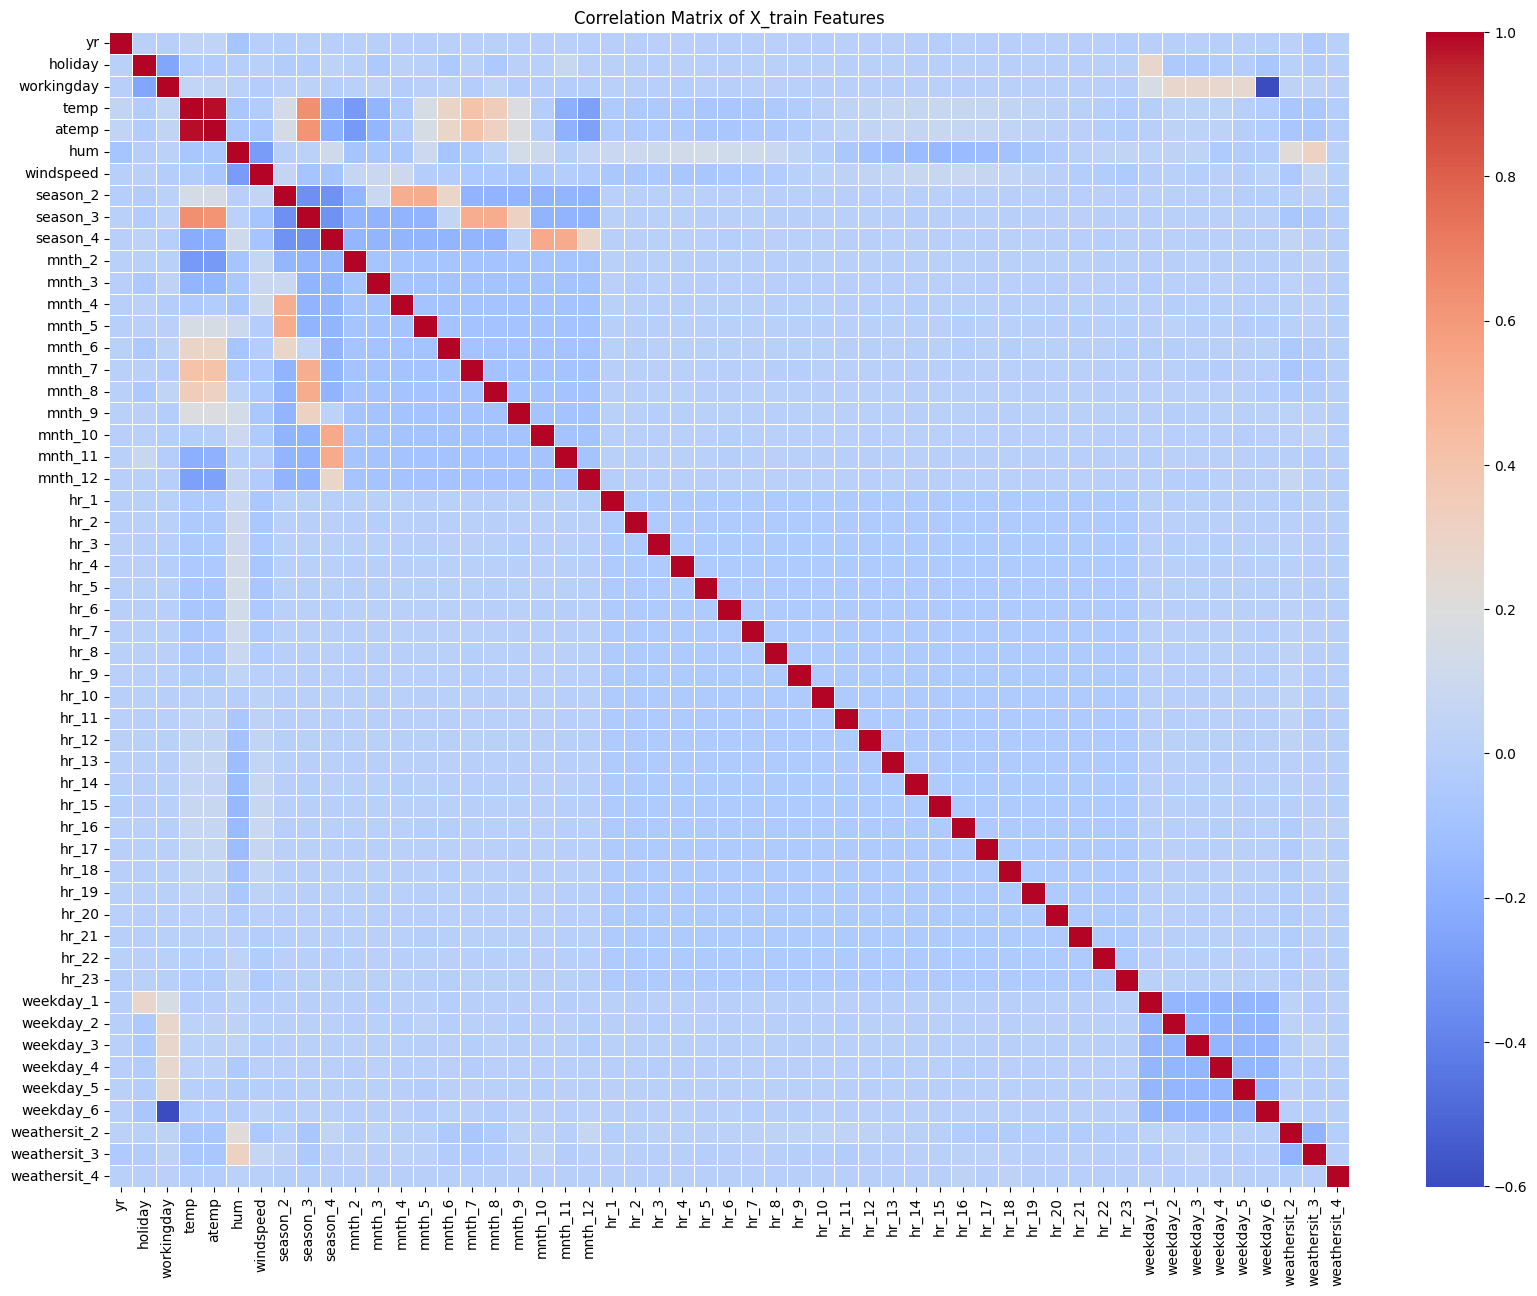

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix_processed = X_train.astype(float).corr()

plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix_processed, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of X_train Features')
plt.show()

It appears that *temp* and *atemp* are way too correlated so we should delete one of them to avoid multicollinearity.
Seasons and months also give similar information but let's keep them for now as it's not that important.

In [9]:
X_train.drop(columns=['atemp'], inplace=True, errors='ignore')
X_test.drop(columns=['atemp'], inplace=True, errors='ignore')

## Hyperparameter optimization
Hyperparameter tuning helps find the best set of hyperparameters for your model. Use Grid Search or Random Search with Cross Validation from scikit-learn to search for the best combination of parameters.

In [11]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    'n_estimators': [300, 500, 700],
    'learning_rate': [0.1, 0.15, 0.2],
    'max_depth': [5, 7, 9]
}

xgb_model = xgb.XGBRegressor(random_state=42)

# Negative mean squared error is used because GridSearchCV maximizes the score, so we minimize the negative MSE
grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search_xgb.fit(X_train, y_train)

print("\nBest parameters for XGBoost found by GridSearchCV:", grid_search_xgb.best_params_)
print("\nBest negative Mean Squared Error for XGBoost (from cross-validation):", grid_search_xgb.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best parameters for XGBoost found by GridSearchCV: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 700}

Best negative Mean Squared Error for XGBoost (from cross-validation): -2336.0367474417344


I tried around 10 different lists of parameters and decided to stop after 2 consecutive executions (with different lists of parameters) gave the same output.

## Train the XGBoost and Linear regression models
Now, create an XGBoost and linear regression model using the best parameters and train them using the training data.

In [12]:
best_xgb_params = grid_search_xgb.best_params_

xgb_model = xgb.XGBRegressor(
    n_estimators=best_xgb_params['n_estimators'],
    learning_rate=best_xgb_params['learning_rate'],
    max_depth=best_xgb_params['max_depth'],
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.2, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=700,
             n_jobs=None, num_parallel_tree=None, ...)

In [13]:
from sklearn.linear_model import LinearRegression

lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)

LinearRegression()

## Make predictions
Use the trained models to make predictions on the test data and compare the performance of the XGBoost and linear regression models using metrics like Mean Squared Error (MSE) and R-squared.

In [14]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred_lr = lin_reg_model.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("\n--- Linear Regression Model Performance ---")
print(f"Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.2f}")
print(f"R-squared (R2): {r2_lr:.2f}")


y_pred_xgb = xgb_model.predict(X_test)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\n--- XGBoost Model Performance ---")
print(f"Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")
print(f"R-squared (R2): {r2_xgb:.2f}")



--- Linear Regression Model Performance ---
Mean Squared Error (MSE): 10100.66
Root Mean Squared Error (RMSE): 100.50
R-squared (R2): 0.68

--- XGBoost Model Performance ---
Mean Squared Error (MSE): 2161.55
Root Mean Squared Error (RMSE): 46.49
R-squared (R2): 0.93


It appears that the XGBoost model is way more precise than the Linear regression Model, but let's visualize that to have some explanation clues.

## Visualize the predictions and compare the mdoels
Create a "Actual vs. Predicted Values" graph to give a visual inspection of the prediction quality.

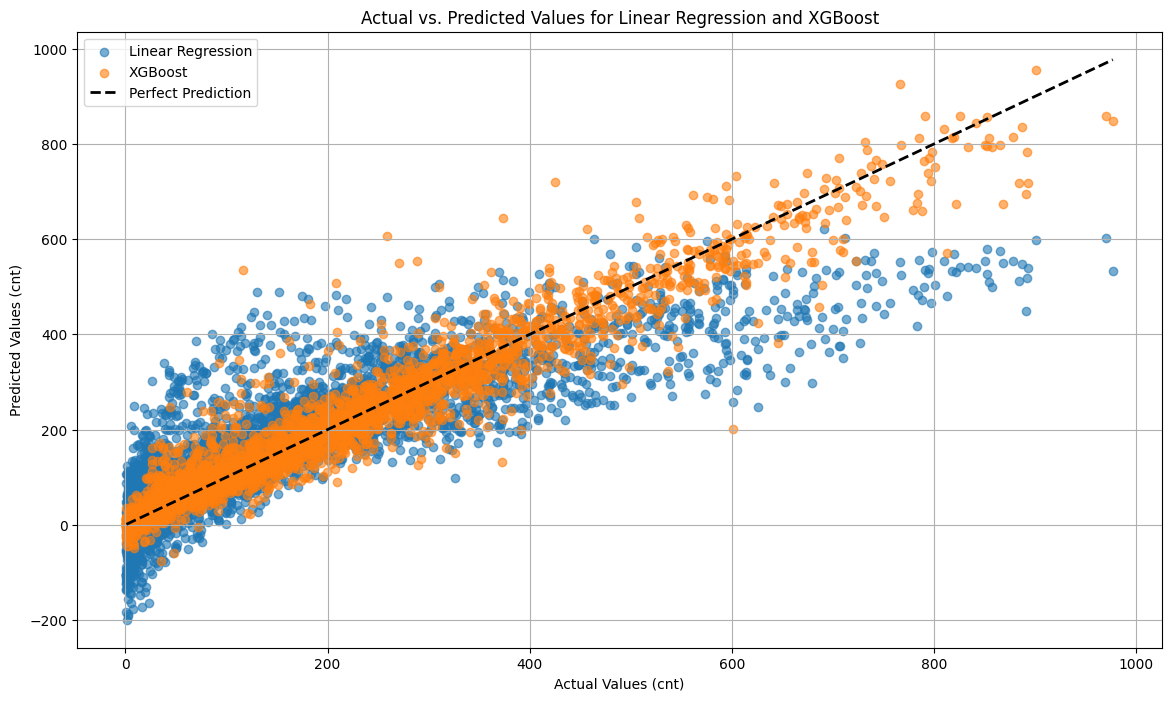

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

plt.scatter(x=y_test, y=y_pred_lr, alpha=0.6, label='Linear Regression')

plt.scatter(x=y_test, y=y_pred_xgb, alpha=0.6, label='XGBoost')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction')

plt.title('Actual vs. Predicted Values for Linear Regression and XGBoost')
plt.xlabel('Actual Values (cnt)')
plt.ylabel('Predicted Values (cnt)')
plt.legend()
plt.grid(True)
plt.show()

It appears that the values close to zero are a big problem in the Linear regression model, as well as the highest values. We can assume that the amount of low values made the fit the "less worse" for these values but it caused to parameters to be inadequate for the highest values, that can be the most important in the context of shared-bike demand.